<a href="https://colab.research.google.com/github/YTChiew/Zara-Sales-Analysis/blob/main/zara_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Notebook Title: Zara Sales Analysis
# Author: YTChiew
# Date: 2026-03-16
# Project: GitHub portfolio

In [6]:
#import libraries
import pandas as pd
import numpy as np

#for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#load datasets
data = pd.read_csv('/content/zara.csv', sep=';')

#display data
data.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [8]:
#Check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

In [9]:
#Check for null values:
data.isnull().sum()

,0
Product ID,0
Product Position,0
Promotion,0
Product Category,0
Seasonal,0
Sales Volume,0
brand,0
url,0
sku,0
name,1


In [10]:
#Check for duplicates:
data.duplicated().sum()

np.int64(0)

Insight:

- The dataset contains of 252 rows and 16 columns
- There are missing values under "name" and "description"
- There are no duplicated records





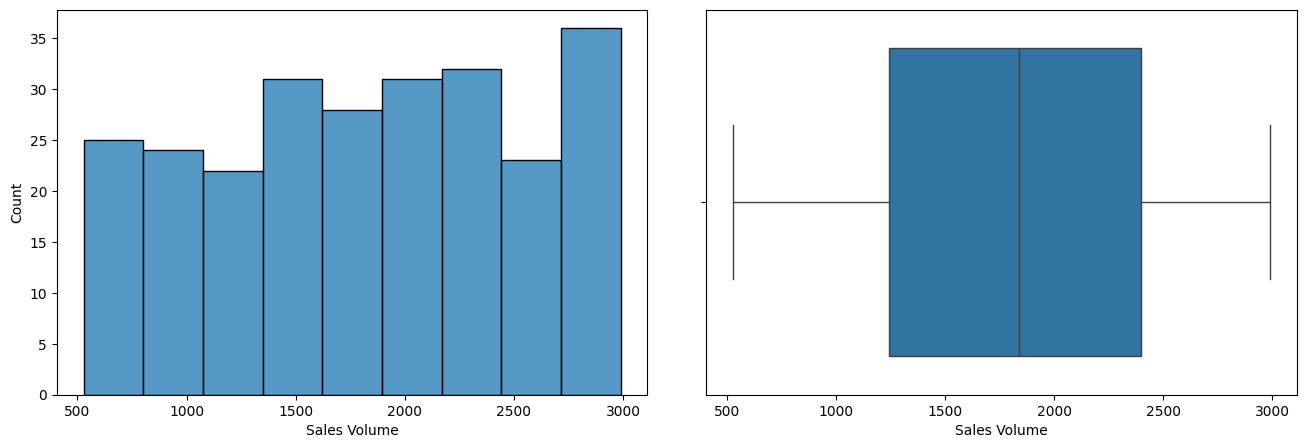

<Figure size 640x480 with 0 Axes>

In [29]:
#Explore numerical columns
##'Product_ID' -> unique identifier
##'Sales Volume' and 'Price' are numerical data

#Univariate Analysis
#Histograms (numerical) -> 'Sales Volume'
fig, axs = plt.subplots(1,2,figsize=(16,5), gridspec_kw={'wspace': 0.1})
sns.histplot(data['Sales Volume'], ax = axs[0])
sns.boxplot(x = data['Sales Volume'], ax = axs[1])
plt.show()

plt.savefig("sales volume_trend.png", bbox_inches="tight")

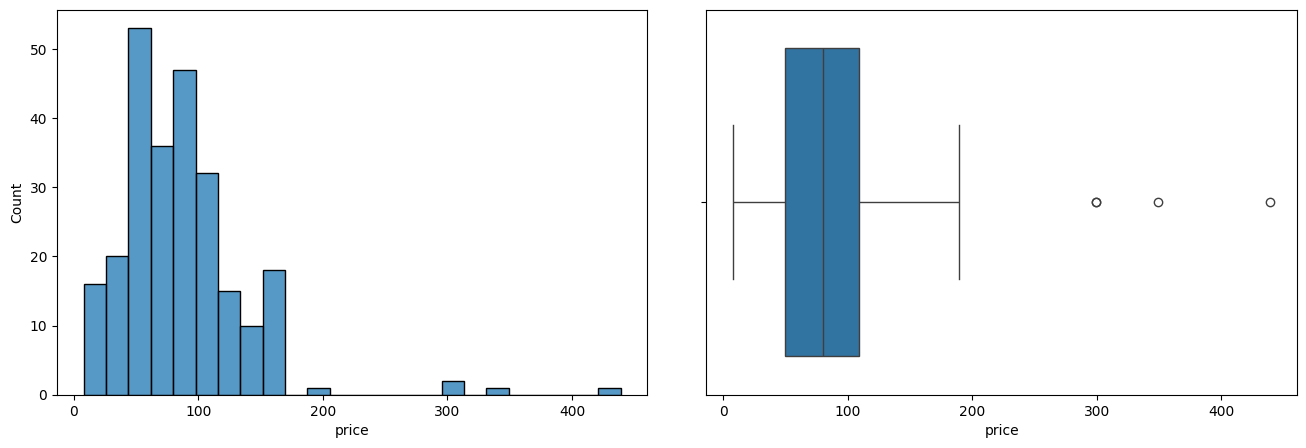

In [15]:
#Price

fig, axs = plt.subplots(1,2,figsize=(16,5), gridspec_kw={'wspace': 0.1})
sns.histplot(data['price'], ax = axs[0])
sns.boxplot(x = data['price'], ax = axs[1])
plt.show()

In [28]:
#Use Interquartile range (IQR) method to identify potential outlier

#First Quartile
Q1 = data['price'].quantile(0.25)
#Third Quartile
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

#Lower bound
lower_bound = Q1 - 1.5*IQR
#Upper bound
upper_bound = Q3 + 1.5*IQR

#Identify Outliers: Any data point lower than the lower bound or higher than the upper bound is an outlier
# | is the bitwise operator, which performs OR operations on the binary representations of numbers.
price_filtered = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]
print("the shape is:" ,price_filtered.shape)

price_filtered.head(5)

the shape is: (4, 16)


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
13,151396,Front of Store,Yes,Clothing,Yes,729,Zara,https://www.zara.com/us/en/cropped-leather-jac...,323134418-800-3,CROPPED LEATHER JACKET,Leather jacket. Cropped length. Lapel collar a...,439.0,USD,2024-02-19T08:50:13.771115,jackets,MAN
22,161909,Aisle,Yes,Clothing,No,1290,Zara,https://www.zara.com/us/en/leather-jacket-p054...,315529534-705-3,LEATHER JACKET,Relaxed fit jacket in leather. Spread collar a...,299.0,USD,2024-02-19T08:50:18.813979,jackets,MAN
38,114877,Aisle,No,Clothing,No,1860,Zara,https://www.zara.com/us/en/suede-jacket-p02521...,323134415-700-3,SUEDE JACKET,Jacket made of suede. Cropped length. Lapel co...,349.0,USD,2024-02-19T08:50:29.497634,jackets,MAN
60,151925,End-cap,Yes,Clothing,Yes,2179,Zara,https://www.zara.com/us/en/vintage-effect-leat...,320774184-800-97,VINTAGE EFFECT LEATHER BOMBER JACKET,NaN,299.0,USD,2024-02-19T08:50:43.543555,jackets,MAN


Insights:
  - A small percentile of price range are between $200 to $500
  - For column 'Sales Volume', the histograms shows an almost uniform distribution, meaning that every possible sales volume within the observed range has an equal chance of occurring. This means there's no inherent bias towards selling more or fewer units within that range